In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# On importe un graphe pour chacune des université
G_caltech = nx.read_gml('./db/Caltech36.gml')
G_mit = nx.read_gml('./db/MIT8.gml')
G_hopkins = nx.read_gml('./db/Johns Hopkins55.gml')

# Question 3
On souhaite meintenant étudier l'assortiment des réseaux selons différents indicateurs.

In [2]:
# On récupère le nom des attributs pour un réseau
node_attributes = set()
first_node = next(iter(G_caltech.nodes(data=True)))
node_attributes.update(first_node[1].keys())

print("Attributes in the Caltech network:", node_attributes)

Attributes in the Caltech network: {'year', 'second_major', 'dorm', 'gender', 'student_fac', 'major_index', 'high_school'}


In [3]:
import os 

data_dir = "./db/"
file_list = os.listdir(data_dir)
networks = []
for f in file_list:
    networks.append(nx.read_gml(data_dir + f))
    
assortativities = {
    'student_fac': [],
    'major_index': [],
    'vertex_degree': [],
    'dorm': [],
    'gender': []
}

sizes = []

for G in networks:
    size = G.number_of_nodes()
    sizes.append(size)

    # On calcule l'assortiment selon le critère
    for attribute in assortativities.keys():
        if attribute == 'vertex_degree':
            assortativity = nx.degree_assortativity_coefficient(G)
        else:
            assortativity = nx.attribute_assortativity_coefficient(G, attribute)
        
        assortativities[attribute].append(assortativity)

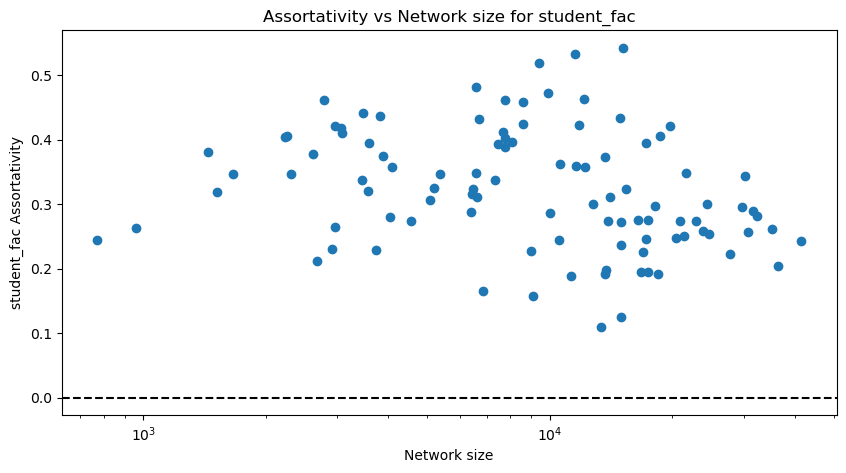

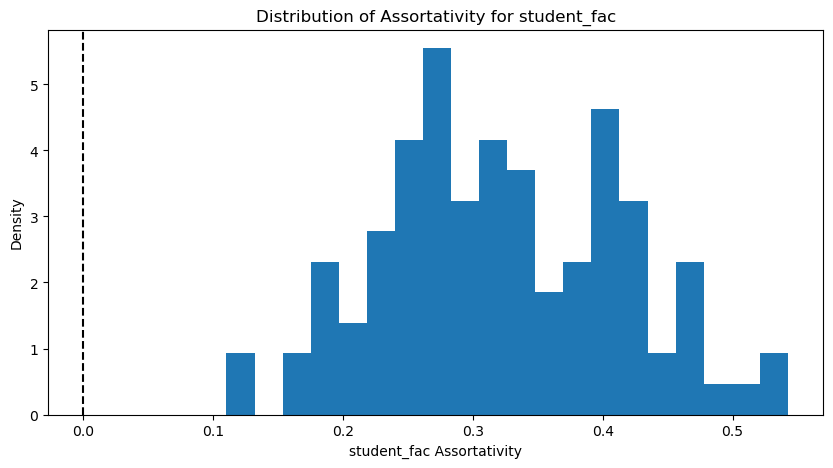

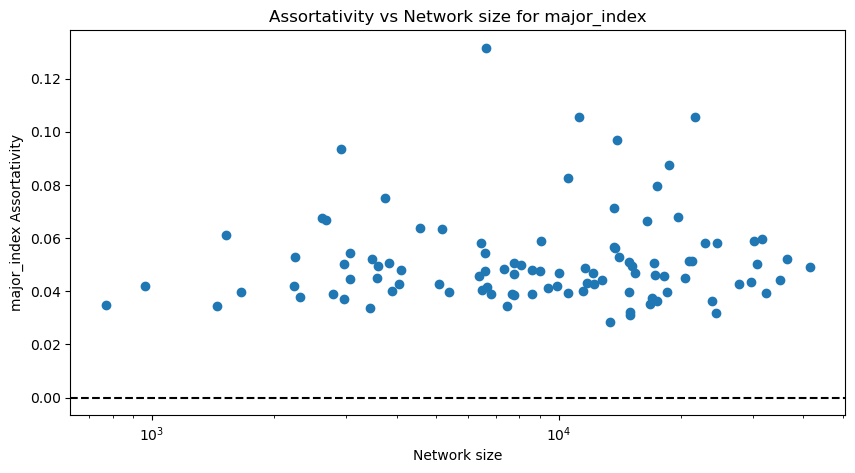

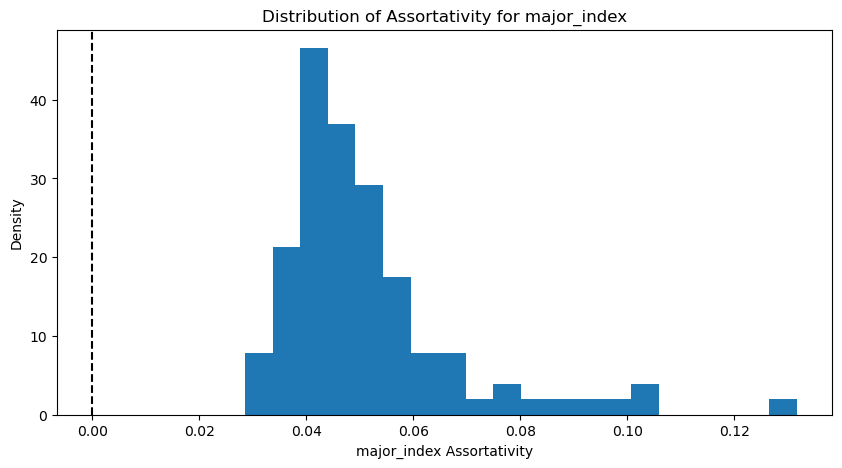

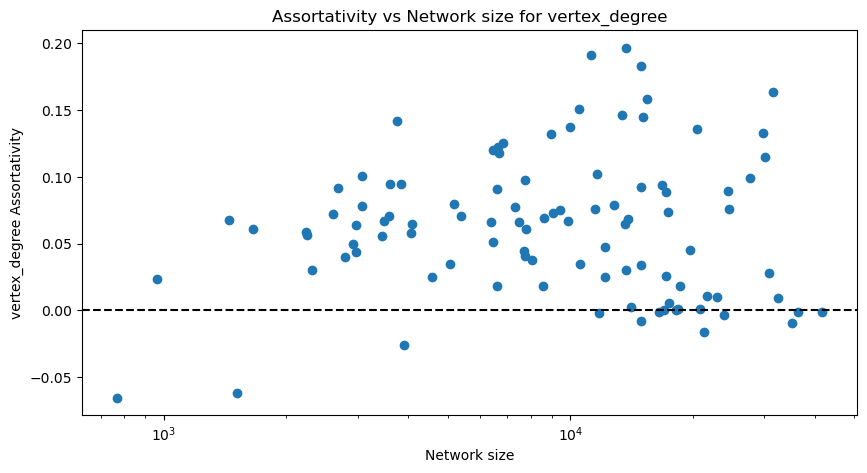

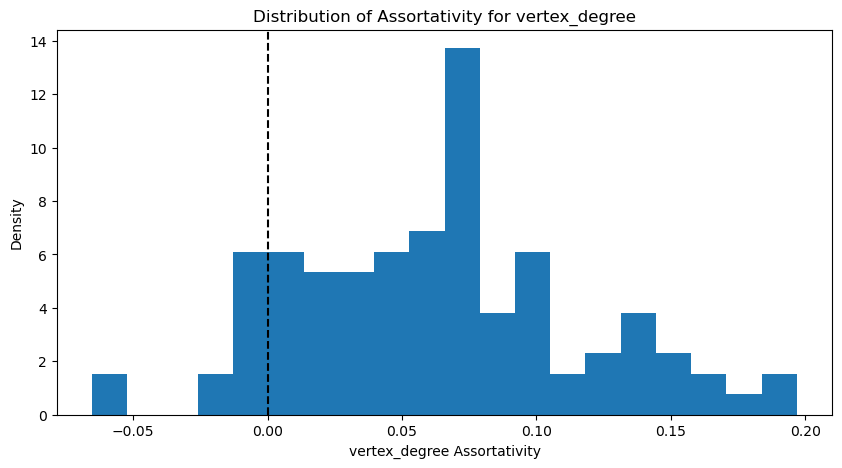

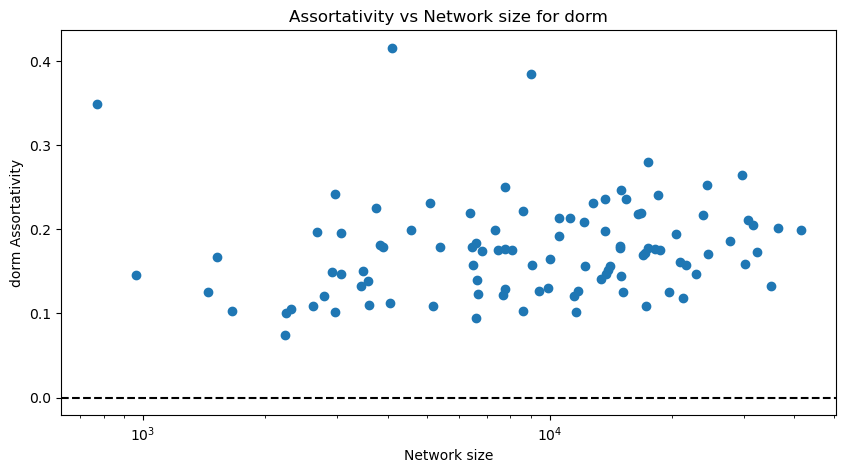

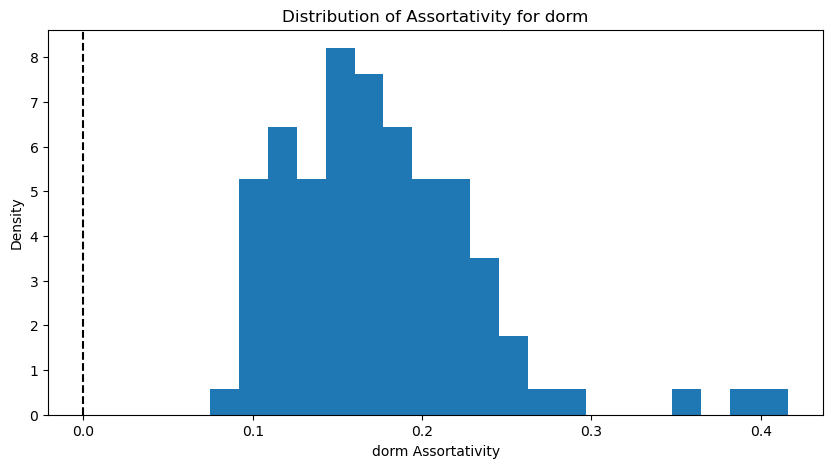

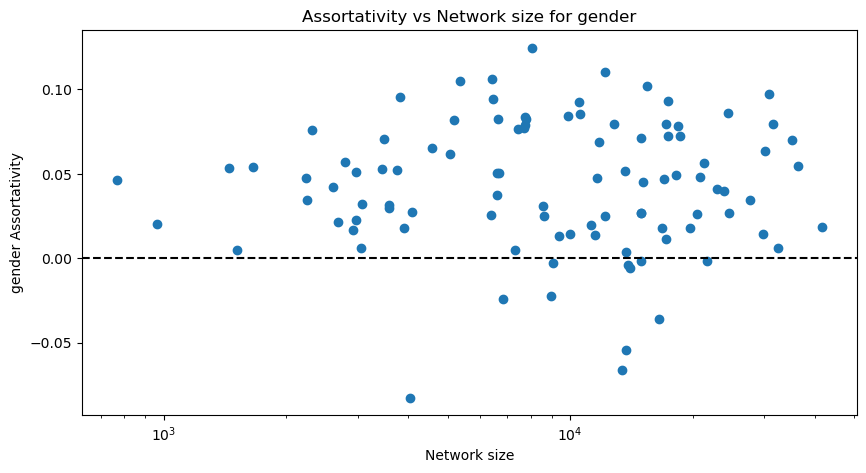

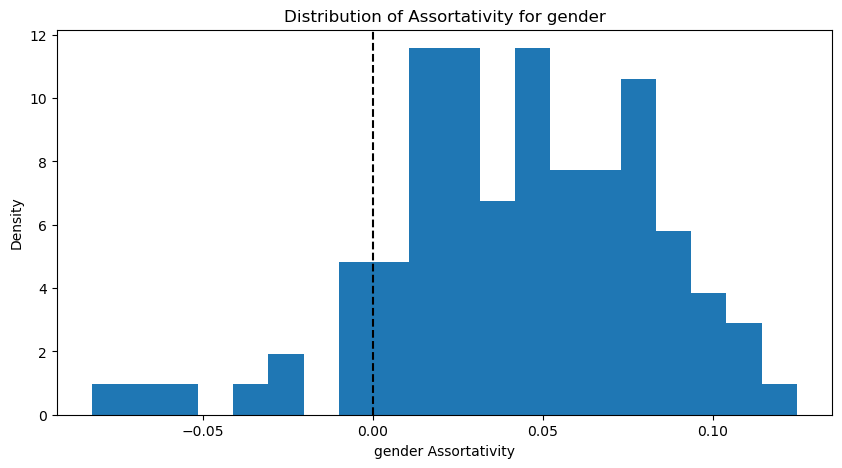

In [5]:
for attribute, values in assortativities.items():
    # On trace l'assortiment en fonction de la taille du réseau
    plt.figure(figsize=(10, 5))
    plt.scatter(sizes, values)
    plt.xscale('log')
    plt.xlabel('Network size')
    plt.ylabel(f'{attribute} Assortativity')
    plt.axhline(y=0, color='black', linestyle='dashed') 
    plt.title(f'Assortativity vs Network size for {attribute}')
    plt.show()

    # On trace l'histogramme de l'assortiment
    plt.figure(figsize=(10, 5))
    plt.hist(values, bins=20, density=True)
    plt.axvline(x=0, color='black', linestyle='dashed') 
    plt.xlabel(f'{attribute} Assortativity')
    plt.ylabel('Density')
    plt.title(f'Distribution of Assortativity for {attribute}')
    plt.show()

## Interprétation
### du statut (student_fac)
 - sur le graphe : L'assortativité varie entre environ 0.1 et 0.5, avec une majorité de valeurs clairement au-dessus de 0. Il n'y a pas de tendance visible par rapport à la taille du réseau.
 - sur l'histogramme : La distribution est centrée autour de 0.3, ce qui indique une forte homogamie (les étudiants se lient aux autres étudiants, de même pour les professeurs).
 - Interprétation : Cette forte homogamie peut s’expliquer par la séparation institutionnelle entre étudiants et enseignants.

### de la majeure (major_index)
 - sur le graphe : Les valeurs sont relativement faibles (majoritairement entre 0.02 et 0.12), sans tendance claire selon la taille.
 - sur l'histogramme : Distribution centrée autour de 0.05, indiquant une faible mais présente homogamie.
 - Interprétation : Cela reflète probablement le fait que les étudiants ont tendance à interagir davantage avec des personnes qui partage leurs cours, projets...

### du dortoir (dorm)
 - sur le graphe : Assortativité également faible à modérée (valeurs allant de légèrement négatives à environ 0.3).
 - sur l'histogramme : Distribution centrée vers 0.1-0.15, ce qui indique une modérée homogamie.
 - Interprétation : Rien de surprenant car les dortoirs sont des espaces partagés et de socialisation.

### du Genre (gender)
 - sur le graphe : Les valeurs sont très proches de 0, avec une légère dispersion autour de cette valeur (positives et négatives).
 - sur l'histogramme : Distribution centrée autour de 0.02.
 - Interprétation : Cela indique une très faible homogamie de genre. Certaines écoles montrent une légère hétérogamie (ce qui peut refléter des interactions genrées, comme les relations amoureuses hétérosexuelles). En moyenne, la tendance est vers une homogamie très modérée.

### du degré du sommet (vertex_degree)
 - sur le graphe : Les valeurs sont proches de 0, avec plusieurs réseaux affichant une assortativité légèrement négative.
 - sur l'histogramme : Distribution centrée autour de 0, avec une queue vers les valeurs négatives.
 - Interprétation : Cela suggère une absence de préférence forte en termes de degré.

D'où on peut classer les attributs de la plus à la moins forte influent :
 1. Statut 2. Dortoir 3. Majeure 4. Genre 5. Degré